Udacity Pytorch project 2: CIFAR-10 Image Classification

Some of the benchmark results on CIFAR-10 include:

 

78.9% Accuracy | [Deep Belief Networks; Krizhevsky, 2010](https://www.cs.toronto.edu/~kriz/conv-cifar10-aug2010.pdf)

 

90.6% Accuracy | [Maxout Networks; Goodfellow et al., 2013](https://arxiv.org/pdf/1302.4389.pdf)

 

96.0% Accuracy | [Wide Residual Networks; Zagoruyko et al., 2016](https://arxiv.org/pdf/1605.07146.pdf)

 

99.0% Accuracy | [GPipe; Huang et al., 2018](https://arxiv.org/pdf/1811.06965.pdf)

 

98.5% Accuracy | [Rethinking Recurrent Neural Networks and other Improvements for ImageClassification; Nguyen et al., 2020](https://arxiv.org/pdf/2007.15161.pdf)

In [206]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transform
#from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets
from torchinfo import summary
import math 
import sys 


In [151]:
#note: bought a refurbed mini mac m4 to get GPUs. cpu was TOO SLOW!!!!! 
#training was taking forever, even for a few epochs!!!!!


In [153]:
print('MPS available',torch.backends.mps.is_available())
print('mps built?',torch.backends.mps.is_built())

MPS available True
mps built? True


In [154]:
#TODO add random_seed to get same outcome 
torch.manual_seed(42) #minor random note: for some reason, 42 is a very common number in stack overflow

In [155]:
print('device:',torch.device('mps' if torch.backends.mps.is_available() else 'cpu'))

device: mps


In [156]:
BATCH_SIZE = 32 #keeping at 4 for DEV... increase later
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

Load the Dataset

Specific your transforms as a list first. The transforms module is already loaded as transforms
CIFAR-10 is fortunately included in the torchvision module. Then you can create your dataset using the CIFAR10 object from torchvision.datasets. Make sure to specify download=True. 
Once your dataset is created, you'll also need to define a Dataloader from the torch.utils.data module for both train and test set



In [265]:
#get mean/std in order to use in transforms 
train_transforms = transform.Compose([     
     transform.ToTensor(),
]) 
trainset = datasets.CIFAR10('data/', download=True, train=True, transform=train_transforms)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)

#borrowing/modifying this snippet from the following URL:
#https://www.codegenes.net/blog/pytorch-calculate-mean-and-std-of-dataset/
#Initialize variables to accumulate sum and sum of squares
mean = torch.zeros(3)   
std = torch.zeros(3)
nb_samples = 0
for data in trainloader:
    imgs, _ = data        #  the usual suspects: batch size, C, H, W
    batch_samples = imgs.size(0)
    imgs = imgs.view(batch_samples, imgs.size(1), -1)  # flatten H×W
    mean += imgs.mean(2).sum(0)     #add dims of each image to the mean tensor
    std += imgs.std(2).sum(0)  #similar, add std to the std tensor 
    nb_samples += batch_samples
#take averages
mean /= nb_samples 
std /= nb_samples  
print('mean:',mean)
print('std:', std) 


mean: tensor([0.4914, 0.4822, 0.4465])
std: tensor([0.2023, 0.1994, 0.2010])


In [258]:
32*32

1024

In [266]:
#Define transforms

# TODO: Define transforms for the training data and testing data
#these transforms are tentative!! Putting something in to get the ball rolling. They may very well suck. 


train_transforms = transform.Compose([     
    transform.RandomHorizontalFlip(p=-.5),
    transform.ToTensor(),
    transform.Normalize(mean=mean, std=std) #from earlier calc
]) 

test_transforms =  transform.Compose([ transform.ToTensor(),transform.Normalize(mean=mean, std=std) ])



#Create training set and define training data loader
trainset = datasets.CIFAR10('data/', download=True, train=True, transform=train_transforms)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)



In [267]:
#Create your test set and define test data loader
testset = datasets.CIFAR10('data/', download=True, train=False, transform=test_transforms)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=True)

#the 10 classes in the dataset
classes=('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')


Explore the Dataset

Using matplotlib, numpy and torch, explore the dimensions of your data 

you can view images using the show5 function below - it takes a dataloader as an argument. Remember that normalized images will look really weird to you. You may want to try changing your transforms to view images.Typically using no transforms other than toTensor() works well for viewing - but not as well for training your network. If show5 doesn't work, go back and check your code for creating your dataloaders and your training/test sets.


In [268]:

print(len(trainset))
print(len(testset))


50000
10000


In [269]:
#didn't actually use this 
def show5(img_loader):
    dataiter=iter(img_loader)

    batch=next(dataiter)
    labels=batch[1][0:5]
    image=batch[0][0:5]
    for i in range(5):
        print(classes[labels[i]])
        image=images[i].numpy()
        plt.imshow(image.T)
        plt.show()
    

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9655808..2.0488436].


bird


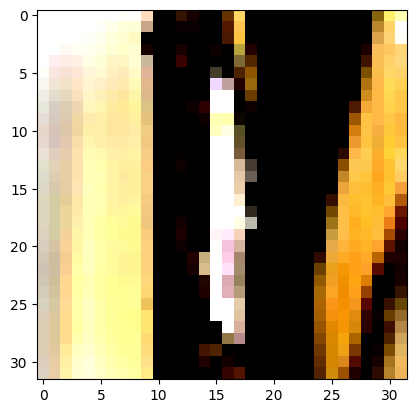

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9262497..2.3052816].


dog


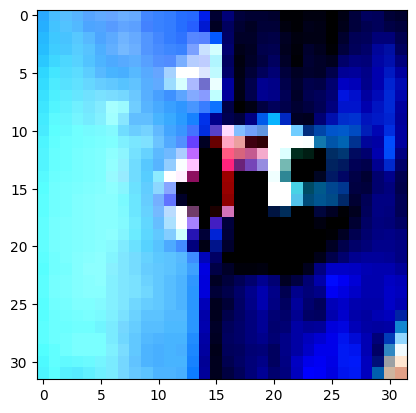

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0853758..1.2005761].


frog


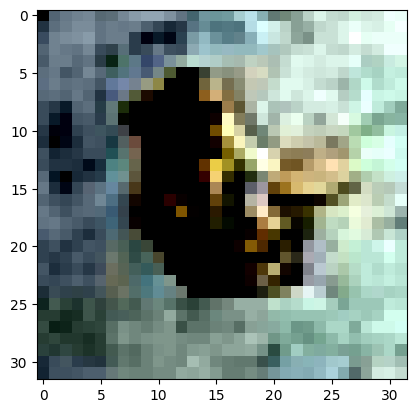

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4096699..2.7150762].


cat


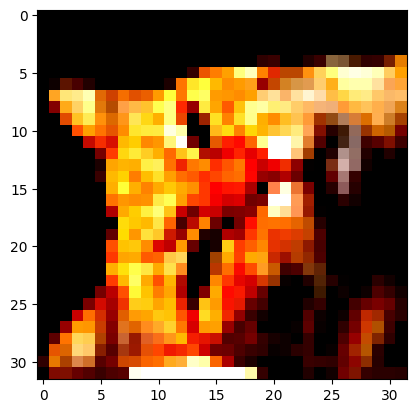

In [283]:

# Run this to test your data loader
images, labels = next(iter(trainloader))
#helper.imshow(images[0], normalize=False)    

dataiter=iter(trainloader)
batch=next(dataiter)
labels=batch[1][0:4]
image=batch[0][0:4]
for i in range(4):
    print(classes[labels[i]])
    image=images[i].numpy()
    plt.imshow(image.T)
    plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.163432..2.4753103].


torch.Size([32, 32])
car


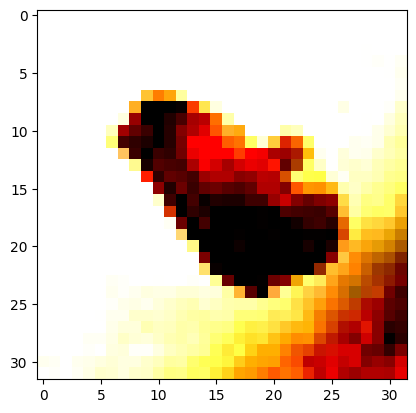

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0801275..1.5938874].


bird


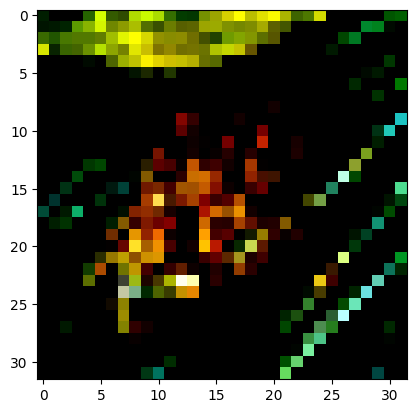

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4178889..2.51408].


ship


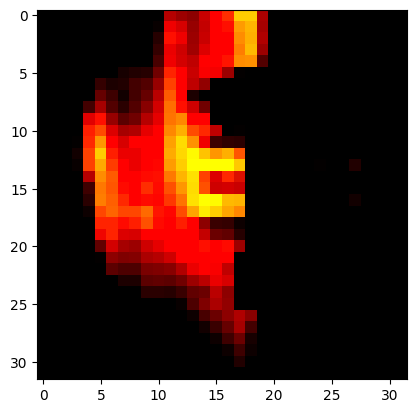

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0639086..2.7541041].


car


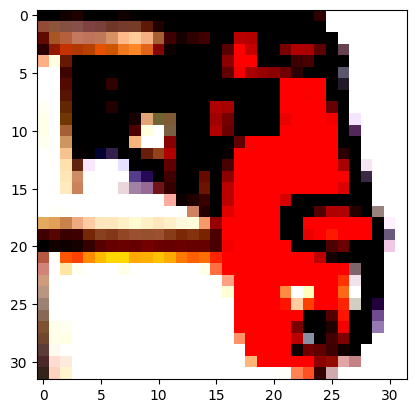

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.273976..2.7541041].


ship


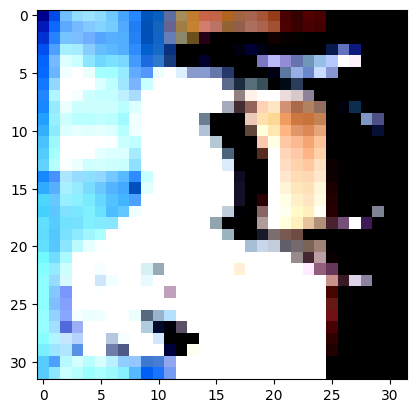

<class 'torch.Tensor'>
torch.Size([32, 3, 32, 32])
torch.Size([32])
32
1563


In [272]:
#this shape looks ok 
next(iter(trainloader))[0].shape

torch.Size([32, 3, 32, 32])

In [273]:
print(3*32*32)

3072


In [274]:
#check out 1 image
image, label = next(iter(dataiter))
print(type(image))
print(image.shape)
print(label.shape)
print(len(image))
one_image, one_label = image[0].unsqueeze(dim=0), label[0]
print(type(one_image))
print(one_image.shape)
#print('multiplied:',one_image.mul())
print(label.shape)
print(len(one_image))


<class 'torch.Tensor'>
torch.Size([32, 3, 32, 32])
torch.Size([32])
32
<class 'torch.Tensor'>
torch.Size([1, 3, 32, 32])
torch.Size([32])
1


Build your Neural Network

Using the layers in torch.nn (which has been imported as nn) and the torch.nn.Functional module (imported as F)
construct a neural network based on the parameters of the dataset. Feel free to consult a model of any architecture-feedforward, convolutional or even something more advanced.

In [238]:
#REFERENCE https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
#torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode='zeros', device=None, dtype=None)

In [239]:
# # #code here to build the network 
# #NOTE: this mock up model was used for debugging and to help find shape mismatchs... 
# class Classifier_shapeprint(nn.Module):
#     def __init__(self,input_shape):
#         super().__init__()
#         self.dropout = nn.Dropout(0.2)
#         self.fc0 = nn.Conv2d(in_channels=input_shape,out_channels=256,kernel_size=3)
#         self.bn1   = nn.BatchNorm2d(256) #same as out_channels previous step
#         #adding a second conv2d.
#         self.fc1 = nn.Conv2d(in_channels=256,out_channels=128,kernel_size=3)
#         self.bn1   = nn.BatchNorm2d(128)
#         self.fc2 = nn.Linear(4608, 64) #NOTE: second conv2d changes shape from 50400 to 4608
       
#         self.fc3 = nn.Linear(64, 128)
#         self.fc4 = nn.Linear(128, 64)
#         self.fc5 = nn.Linear(64, 10)
#         #TODO incorporate this. 
#         self.dropoutprobability = 0
#         #self.dropout = nn.Dropout(self.dropoutprobability) 
        
#     def forward(self, x):
#         x = self.dropout(x)
#         #x = self.bn1(x)
#         #x = self.fc0(x)
#         x = F.relu(self.fc0(x))
        
#         print(x.shape)
    
#         x = F.max_pool2d(x,2)
        
#         print(x.shape)
#         x = F.relu(self.fc1(x))
#         #x = self.bn1(x)
#         print(x.shape)
#         # make sure input tensor is flattened
#         x = F.max_pool2d(x,2)
#         print(x.shape)
#         x = x.view(x.shape[0], -1)
#         print(x.shape)
        
#         x = F.relu(self.fc2(x))
#         print(x.shape)
#         x = F.relu(self.fc3(x))
#         print(x.shape)
#         x = F.relu(self.fc4(x))
#         print(x.shape)
#         x = F.relu(self.fc5(x))
#         print(x.shape)
#         x = F.log_softmax(x, dim=1)
#         print(x.shape)
#         return x
#code for loss fx and optimizer here
# model = Classifier_shapeprint(input_shape=3).to(DEVICE)
# criterion = nn.NLLLoss(reduction='sum')
# optimizer = optim.Adam(model.parameters(), lr=0.003)


In [240]:
# # quick test on 1 epoch for training.... 

# epochs = 1

# for e in range(epochs):
#     print('churning thru epoch number:',e)
#     running_loss = 0
#     model.train()
#     for images, labels in trainloader:
#         images, labels = images.to(DEVICE), labels.to(DEVICE)
#         log_ps = model(images)
#         loss = criterion(log_ps, labels)
        
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
        
#         running_loss += loss.item()
#         sys.exit()
#     else:
#         print(f"Training loss: {running_loss/len(trainloader)}")
#         sys.exit()
# print('fini')

In [275]:
#code here to build the network 
#note to self.. added dropout. 20% to start 
class Classifier(nn.Module):
    def __init__(self,input_shape):
        super().__init__()
        self.dropout = nn.Dropout(0.2) 
        self.conv1 = nn.Conv2d(in_channels=input_shape,out_channels=128,kernel_size=3,padding=1)
        #adding a second conv2d.
        self.conv2 = nn.Conv2d(in_channels=128,out_channels=64,kernel_size=3,padding=1)
        self.conv3 = nn.Conv2d(in_channels=64,out_channels=32,kernel_size=3,padding=1)
        self.fc1 = nn.Linear(800, 32)
        self.fc2 = nn.Linear(32, 10)
       
    def forward(self, x):
        x = self.dropout(x)
        
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x,kernel_size=2,stride=2,padding=1)
        x = F.relu(self.conv2(x))
  
        x = F.max_pool2d(x,kernel_size=2,stride=2,padding=1)        
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x,kernel_size=2,stride=2,padding=1)
        
        # make sure input tensor is flattened
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
 
        return x
model = Classifier(input_shape=3)
model=model.to(DEVICE)


Specify a loss function and an optimizer and instantiate the model.
if you use a less common loss function, please note why you chose that function in a comment. 

In [276]:
#code for loss fx and optimizer here
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


Running your Neural Network 

use whatever method you like to train your neural network and ensure you record the average loss at each epoch. Don't forget to use torch.device() and the .to() method for both your model and data if you are using GPU

if you want to print your loss during each epoch, you can use the enumerate function and print the loss after a set of batches. 250 batches works well for most people. 

In [277]:
#quick train network through 1 epoch (help with fast QC) before the main train (next cell)
epochs = 1

for e in range(epochs):
    print('churning thru epoch number:',e)
    running_loss = 0
    model.train()
    for images, labels in trainloader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        log_ps = model(images)
        loss = criterion(log_ps, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        #sys.exit()
    else:
        print(f"Training loss: {running_loss/len(trainloader)}")
        #sys.exit()
print('fini')

churning thru epoch number: 0
Training loss: 1.4954418339793376
fini


In [278]:
#code to run the network 

epochs = 20 #seems like a reasonable number to at least see if it's going in the right direction

train_losses, test_losses, test_accuracies = [], [], []
for e in range(epochs):
    print('churning thru epoch:',e)
    tot_train_loss = 0
    model.train()
    for images, labels in trainloader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        log_ps = model(images)
        loss = criterion(log_ps, labels)
        tot_train_loss += loss.item()
        
        loss.backward()
        optimizer.step()
    else:
        tot_test_loss = 0
        test_correct = 0  # Number of correct predictions on the test set
        
        # # Turn off gradients for validation, saves memory and computations
        with torch.no_grad():
            model.eval()
            for images, labels in testloader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                log_ps = model(images)
                loss = criterion(log_ps, labels)
                tot_test_loss += loss.item()

                ps = torch.exp(log_ps)
                top_p, top_class = ps.topk(1, dim=1)
                equals = top_class == labels.view(*top_class.shape)
                test_correct += equals.sum().item()

        # Get mean loss to enable comparison between train and test sets
        train_loss = tot_train_loss / len(trainloader.dataset)
        test_loss = tot_test_loss / len(testloader.dataset)

        # At completion of epoch
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        test_accuracies.append(test_correct / len(testloader.dataset))
        print("Epoch: {}/{}.. ".format(e+1, epochs),
              "Training Loss: {:.3f}.. ".format(train_loss),
              "Test Loss: {:.3f}.. ".format(test_loss),
              "Test Accuracy: {:.3f}".format(test_correct / len(testloader.dataset)))
    
print('done')

churning thru epoch: 0
Epoch: 1/20..  Training Loss: 0.037..  Test Loss: 0.035..  Test Accuracy: 0.608
churning thru epoch: 1
Epoch: 2/20..  Training Loss: 0.032..  Test Loss: 0.035..  Test Accuracy: 0.611
churning thru epoch: 2
Epoch: 3/20..  Training Loss: 0.030..  Test Loss: 0.033..  Test Accuracy: 0.644
churning thru epoch: 3
Epoch: 4/20..  Training Loss: 0.029..  Test Loss: 0.033..  Test Accuracy: 0.634
churning thru epoch: 4
Epoch: 5/20..  Training Loss: 0.027..  Test Loss: 0.035..  Test Accuracy: 0.624
churning thru epoch: 5
Epoch: 6/20..  Training Loss: 0.026..  Test Loss: 0.035..  Test Accuracy: 0.627
churning thru epoch: 6
Epoch: 7/20..  Training Loss: 0.026..  Test Loss: 0.032..  Test Accuracy: 0.657
churning thru epoch: 7
Epoch: 8/20..  Training Loss: 0.025..  Test Loss: 0.034..  Test Accuracy: 0.651
churning thru epoch: 8
Epoch: 9/20..  Training Loss: 0.025..  Test Loss: 0.032..  Test Accuracy: 0.660
churning thru epoch: 9
Epoch: 10/20..  Training Loss: 0.024..  Test Loss:

Plot the training loss (and validation loss/accuracy, if recorded)

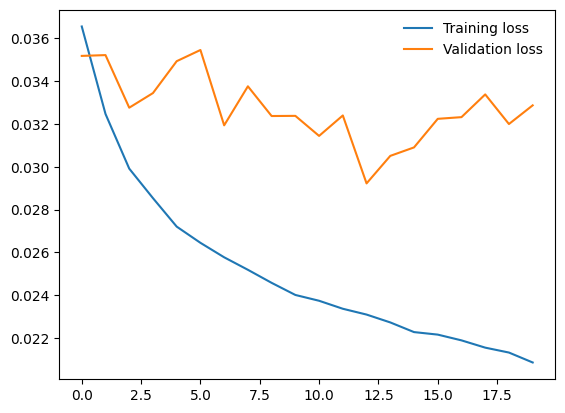

In [279]:
#showing the plots 
plt.plot(train_losses, label='Training loss')
plt.plot(test_losses, label='Validation loss')
plt.legend(frameon=False)

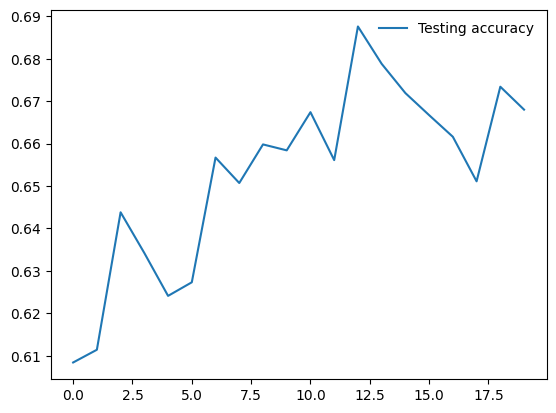

In [280]:

plt.plot(test_accuracies, label='Testing accuracy')
plt.legend(frameon=False)

Testing your model 

using the previously created DataLoader for the test set, compute the percentage of correct predictions using the highest probability prediction. 

If your accuracy is under 45% you'll need to make improvements. Go back and check your model architecture, loss function, and optimizer to make sure they are appropriate for an image classification task. 

Saving your model 

using torch.save, save your model for future loading

In [281]:
#code to save the model 
torch.save(model.state_dict(), "CIFAR_model_final.pth")

Make a recommendation

Based on your evaluation, what is your recommendation on whether to build or buy? Explain your reasoning below. 

In [248]:
#put your explanation here. 

I would recommend buying from the vendor instead of using my model. 

Why? 

For several reasons. First, if retraining is involved in the future, it takes resources. When I started this project, I thought I had enough firepower with a 64GB Linux cpu (which runs through machine learning very quickly) but I found even doing 10 epochs of a neural network took a long time (think over half an hour just for 1 round). If using a cpu, trying to find the right combination of layers and settings for each layer takes "forever" when each round takes so long (and then with a small batch size). Maybe running the model through 100 epochs could get better results, but this assumes you have lots of time (using the cpu). 

After finding out the limitations of using cpu the hard way, I did some research and found that Mac has a series of gpu machines (think M1 through M5), and I found an inexpensive refurbished Mini Mac M4 machine online. While this greatly increased the speed compared to using a cpu (by a factor of at least 10), it's still relatively slow compared to machine learning where you can run a grid search and try hundreds or thousands of combinations of parameters to see what works best on the model. 

Second, and more importantly, while I was able to get pretty close with test accuracy to the mid 60s (on the M4 machine), it's significantly better than chance, but not as good as the 70% achieved by the product seller. Given enough time, could I achieve that? I'd like to believe that with additional tweaks to the process (adjusting batch size, learning rate, more epochs, changing/adding/subtracting neural layers, etc.), but, given time constraints, and that there is a time limit allowed by my employer to take this course, I think for the moment, it makes more sense to go with buying the model. 